# Instantaneous State InSAR


### Introduction

This notebook implements a workflow for time series analysis of point scatterers (PS), including:

- PS selection from amplitude data  
- Time series analysis using:
  - Batch Parameter Estimation (BE)
  - Instantaneous State Estimation (ISE)  
- Anomaly detection based on ISE  

**Batch Estimation:**  
- Linear deformation model with temperature dependence  
- Parameters: constant velocity, thermal expansion  

**Instantaneous State Estimation:**  
- Temporally correlated velocity model with temperature dependence  
- States: instantaneous position, instantaneous velocity, thermal expansion  

---

### Notebook structure

1. Load TerraSAR-X data (e.g., phase, amplitude)  
2. Load meteorological data (temperature-related signal)  
3. Select PS from amplitude (e.g., normalized median amplitude deviation, NMAD)  
4. Perform BE  
5. Perform ISE  
6. Compare BE and ISE  
7. Analyze one PS with varying smoothness constraints  
8. Perform anomaly detection  

---

### Link to download the datasets: 

conda environment (environment.yml): https://surfdrive.surf.nl/s/Dao3FxkypsewRPp

pip requirements (requirements.txt): https://surfdrive.surf.nl/s/BMxLYmmNmqYPMtz

TerraSAR-X: https://surfdrive.surf.nl/s/HF2pBzPd87YJkNX

Meteorological data: https://surfdrive.surf.nl/s/xMbfazpZ2T7Qabi

Python package for Instantaneous state InSAR: https://surfdrive.surf.nl/s/7MjWAF4CWxtpPxZ

Python package for batch estimation (LAMBDA): https://surfdrive.surf.nl/s/bRqejZQc3yZ8t3d

Python package for other required functions: https://surfdrive.surf.nl/s/mCEyWNpLZxdPXP6

password: fringe_2026

# Import packages

In [ ]:
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import contextily as ctx
from pyproj import Transformer
import matplotlib.colors as mcolors

from read_data import *
from instantaneous_state_estimation import *

# Set parameters

In [2]:
# ===============================
# general parameter
# ===============================
wavelength = 0.031 # wavelength of the TerraSAR-X data [m]
# compute factors of m, mm and phs(rad)
phs2m = -wavelength / (4 * np.pi)
phs2mm = phs2m*1000
m2phs = -(4 * np.pi) / wavelength
mm2phs = m2phs/1000
cycle_mm = wavelength/2*1000



# ===============================
# parameters used for batch estimation
# ===============================
# Initial gauss for the sigma of the unknown parameters
sigma_offset = 0.005 # m
sigma_vel =  0.002 # m/yr
sigma_h = 3 # m
sigma_ther = 0.00005 # m/°C

# the option for the LAMBDA method
# method == 1: ILS with shrinking search
# method == 2: Integer rounding
# method == 3: Integer bootstrapping
# method == 4: PAR
# method == 5: ILS with Ratio Test
method = 3


# ===============================
# parameters used for instantaneous state estimation
# ===============================
init_len = 30 # number of epochs used for the initialization
sigma_v = 0.01 # sigma of the instantaneous velocity [m/yr]
L = 150/365 # correlation time of the instantaneous velocity [yr]



# ===============================
# parameters used for anomaly detection
# ===============================
alpha = 0.05  # significance level of testing
q = 1  # the number of updated observation


# ===============================
# define colors for plots
# ===============================
color_amp = '#2ca02c'  # amplitude (green)
color_full = '#1f77b4'   # batch (blue)
color_is = '#ff7f0e'    # instantaneous state (orange)

# Load TSX dataset

In [ ]:
# Path to the input TerraSAR-X CSV file
insar_file_dsc = 'grimburwal_tsx_dsc_t139.csv'

# Load CSV as GeoDataFrame and extract:
# - insar_gpd: GeoDataFrame
# - insar_days: acquisition days
# - filter_def: displacement columns
# - filter_amp: amplitude columns
insar_gpd, insar_dates, insar_days, filter_def, filter_amp = csv2gpd(insar_file_dsc)

# Convert time axis from days to years (useful for modeling or interpretation)
years = insar_days / 365

# Number of spatial points (e.g., persistent scatterers / arcs)
num_arcs = len(insar_gpd)

# Number of temporal observations (epochs)
num_epochs = len(filter_def)

# Create a mask to select points with non-zero amplitude at all epochs
mask_amp_nozero = (insar_gpd[filter_amp] != 0).all(axis=1)

# Filter out points with zero amplitude values and create a clean copy
insar_gpd = insar_gpd[mask_amp_nozero].copy()


# Read meteorological data (temperature)

In [ ]:
# Path to the weather data file (e.g., KNMI station data at Schiphol)
weather_data_file = 'weather_data_schiphol.txt'

# Define a cutoff date to restrict the time range
threshold = datetime(2020, 9, 1)

# Convert DatetimeIndex to a list for filtering operations
dates_list = insar_dates.tolist()

# Keep only dates earlier than the threshold
dates_list = [date for date in dates_list if date < threshold]

# Specify which weather variables to extract (e.g., TG = mean daily temperature)
data_columns = ["TG"]

# Read weather data corresponding to the selected dates and variables
weather_data = read_weather_data(
    weather_data_file,
    dates=dates_list,
    requested_data_columns=data_columns
)

# Extract temperature time series into a NumPy array
temp = np.array([t["TG"] for t in weather_data.values()])


# Spatial plot of the original dataset

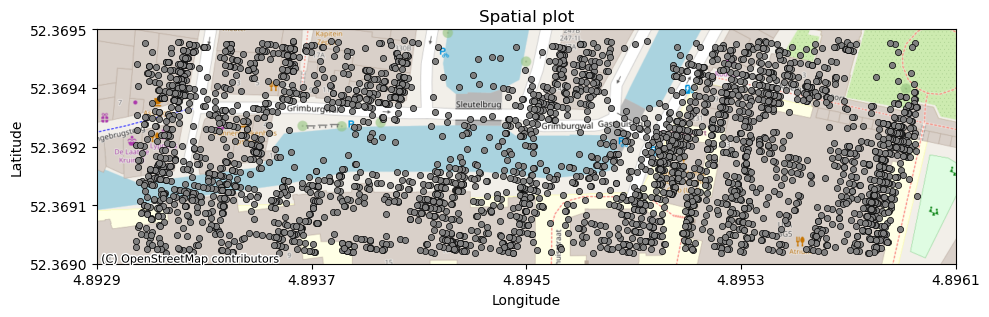

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Spatial plot'}, xlabel='Longitude', ylabel='Latitude'>)

In [5]:
plot_insar_map(
    insar_gpd,
    values=None,
    title="Spatial plot",
    vmin=None,
    vmax=None,
    cmap='jet_r',
    point_size=20,
    zoom=19,
    fixed_color='gray',
    cbar_label=None
)

#  Choose an area of interest (AoI)

In [6]:
# Define Area of Interest (AOI) using geographic bounding box (longitude/latitude)
lon_min = 4.8933 
lon_max = 4.8945

lat_min = 52.36905
lat_max = 52.3694

# Create a spatial mask to select points within the AOI
mask = (
    insar_gpd['pnt_lon'].between(lon_min, lon_max) &
    insar_gpd['pnt_lat'].between(lat_min, lat_max)
)

# Extract subset of InSAR points located inside the AOI
gdf_aoi = insar_gpd[mask].copy()


# Spatial plot of the AoI

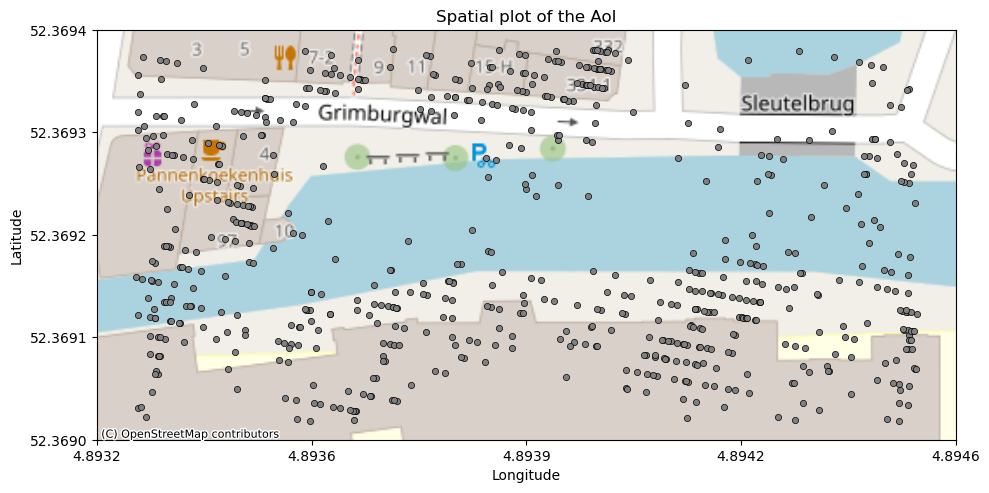

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Spatial plot of the AoI'}, xlabel='Longitude', ylabel='Latitude'>)

In [7]:
plot_insar_map(
    gdf_aoi,
    values=None,
    title="Spatial plot of the AoI",
    vmin=None,
    vmax=None,
    cmap='jet_r',
    point_size=20,
    zoom=19,
    fixed_color='gray',
    cbar_label=None
)

# PS selection with amplitude (NMAD)

In [8]:
# select PS with NMAD smaller than the threshold value
nmad_max = 0.3

In [9]:
# Initialize columns to store point-wise quality metrics
# - nmad_pnt: normalized median absolute deviation (NMAD) of amplitude
# - phs_sigma_pnt: estimated phase standard deviation derived from NMAD
gdf_aoi["nmad_pnt"] = np.nan
gdf_aoi["phs_sigma_pnt"] = np.nan

# Loop over all points in the AOI to compute quality indicators
for j in range(len(gdf_aoi)):

    # Access point by index
    pnt_index = gdf_aoi.index[j]
    pnt = gdf_aoi.loc[pnt_index]

    # Extract amplitude time series for the current point
    amp_pnt = pnt[filter_amp].values

    # Compute NMAD as a robust variability metric
    median_ampl, mad_ampl, nmad_pnt = NMAD(amp_pnt)

    # Convert NMAD to phase noise standard deviation using empirical model
    phs_sigma_pnt = NMAD_to_sigma_phase(nmad_pnt)

    # Store computed metrics in the GeoDataFrame
    gdf_aoi.loc[pnt_index, "nmad_pnt"] = nmad_pnt
    gdf_aoi.loc[pnt_index, "phs_sigma_pnt"] = phs_sigma_pnt

# Select subset of points with acceptable quality (low NMAD)
gdf_sub = gdf_aoi[gdf_aoi["nmad_pnt"] < nmad_max].copy()

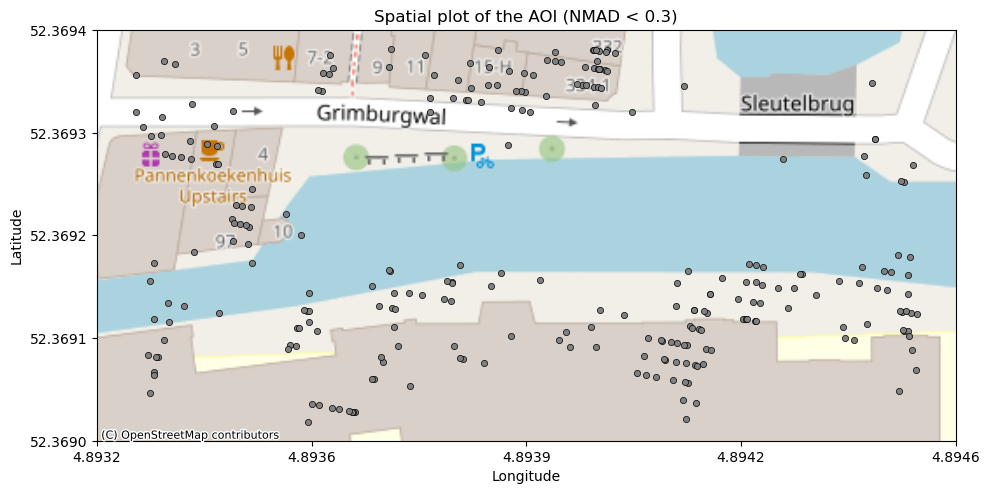

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Spatial plot of the AOI (NMAD < 0.3)'}, xlabel='Longitude', ylabel='Latitude'>)

In [10]:
plot_insar_map(
    gdf_sub,
    values=None,
    title = f"Spatial plot of the AOI (NMAD < {nmad_max})",
    vmin=None,
    vmax=None,
    cmap='jet_r',
    point_size=20,
    zoom=19,
    fixed_color='gray',
    cbar_label=None
)

<div style="background-color:#FAE99E; color: black; vertical-align: middle; padding:3px 20px;">
<p>

## Question 1:
Choose different NMAD thresholds. How does the selection of point scatterers vary?

</p>
</div>

# Select nmad_max = 0.3 for the following processing after finishing Q.1

# Batch estimation

In [11]:
num_arcs = len(gdf_sub)
vel_lin_bat = np.zeros(num_arcs)

for j in range(len(gdf_sub)):
    # get the phase time series
    def_pnt = gdf_sub.iloc[j][filter_def].to_numpy(dtype=float)
    # convert from meters to radians
    phs_wrapped = def_pnt*m2phs

    # get the amplitude time series
    amp_pnt = gdf_sub.iloc[j][filter_amp].to_numpy(dtype=float)

    # get the NMAD
    median_ampl, mad_ampl, nmad_pnt = NMAD(amp_pnt)

    # derive the quality (sigma) of the phase
    phs_sigma_pnt = NMAD_to_sigma_phase(nmad_pnt)
    nmad_pnt_ts = np.full(num_epochs, nmad_pnt)
    sigma_phs_apri = np.full(num_epochs, phs_sigma_pnt)

    A = design_matrix_linear(wavelength, years, temp)
    x_hat, Q_xhat, y_hats, phs_unw = lambda_estimation(
        wavelength,
        phs_wrapped,
        sigma_phs_apri,
        years,
        temp,
        sigma_offset,
        sigma_vel,
        sigma_ther,
        method,
    )

    # Get the phase for estimated DD observation, non-thermal displacement, height difference and thermal expension [rad]
    phs_est = A@x_hat
    dis_est =  A[:,:2]@x_hat[:2]
    phs_ther = A[:,2]*x_hat[2]
    vel_lin_bat[j] = x_hat[1]
    

# Spatial plot with batch solution

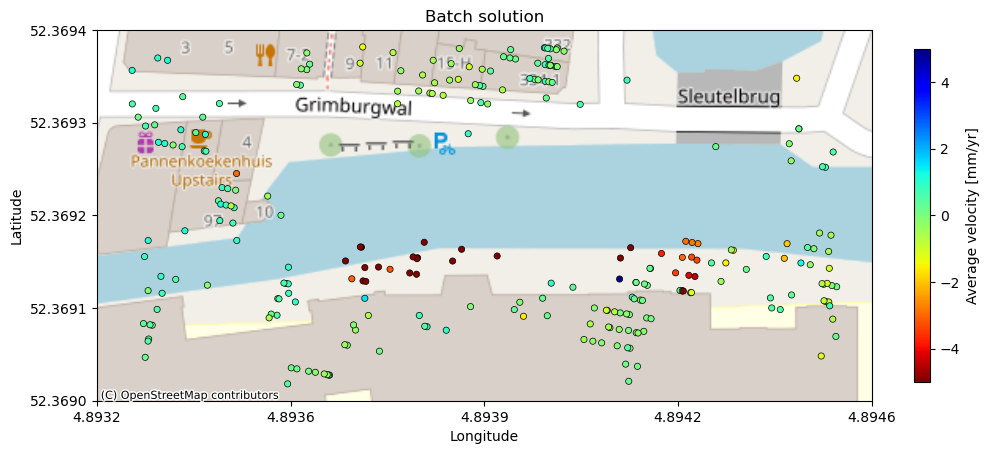

(<Figure size 1000x1000 with 2 Axes>,
 <Axes: title={'center': 'Batch solution'}, xlabel='Longitude', ylabel='Latitude'>)

In [12]:
plot_insar_map(
    gdf_sub,
    values=vel_lin_bat*1000,
    title = "Batch solution",
    vmin=-5,
    vmax=5,
    cmap='jet_r',
    point_size=20,
    zoom=19,
    fixed_color=None,
    cbar_label='Average velocity [mm/yr]'
)

# (Recursive) Instantaneous state estimation

In [13]:
vel_lin_rec = np.zeros(num_arcs)


for j in range(len(gdf_sub)):
    # get the phase time series
    def_pnt = gdf_sub.iloc[j][filter_def].to_numpy(dtype=float)
    # convert from meters to radians
    phs_wrapped = def_pnt*m2phs

    # get the amplitude time series
    amp_pnt = gdf_sub.iloc[j][filter_amp].to_numpy(dtype=float)

    # get the NMAD
    median_ampl, mad_ampl, nmad_pnt = NMAD(amp_pnt)

    # derive the quality (sigma) of the phase
    phs_sigma_pnt = NMAD_to_sigma_phase(nmad_pnt)
    nmad_pnt_ts = np.full(num_epochs, nmad_pnt)
    sigma_phs_apri = np.full(num_epochs, phs_sigma_pnt)


    x_hats_fm, Qx_hats_fm, y_hats_fm, y_hats_unw_fm, \
    x_hats_ft, Qx_hats_ft, y_hats_ft, y_hats_unw_ft = init_rec_estimation(
        init_len,
        wavelength,
        phs_wrapped,
        sigma_phs_apri,
        years,
        temp,
        sigma_v,
        L,
        sigma_offset,
        sigma_vel,
        sigma_ther,
        method,
        recursive_update
    )

    dis_fm, vel_fm, temp_fm = x_hats_fm.T
    # calculate the sum of displacement and residual
    dis_rec_fm = (y_hats_unw_fm - y_hats_fm)*(-wavelength/(4*np.pi))+dis_fm

    # calculate the constant valocity with a linear model
    y_fitted, poly_fn, coeffs = polynomial_fitting(years, dis_rec_fm, degree=1)
    vel_lin = coeffs[0]

    # store the variables
    vel_lin_rec[j] = vel_lin



# Spatial plot with IS solution

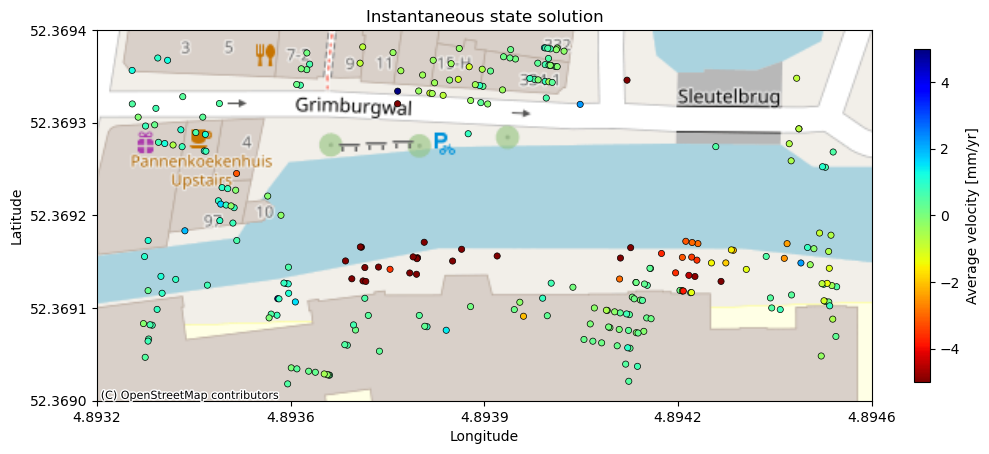

(<Figure size 1000x1000 with 2 Axes>,
 <Axes: title={'center': 'Instantaneous state solution'}, xlabel='Longitude', ylabel='Latitude'>)

In [14]:
plot_insar_map(
    gdf_sub,
    values=vel_lin_rec*1000,
    title = "Instantaneous state solution",
    vmin=-5,
    vmax=5,
    cmap='jet_r',
    point_size=20,
    zoom=19,
    fixed_color=None,
    cbar_label='Average velocity [mm/yr]'
)

# Plot diffrence between batch and IS

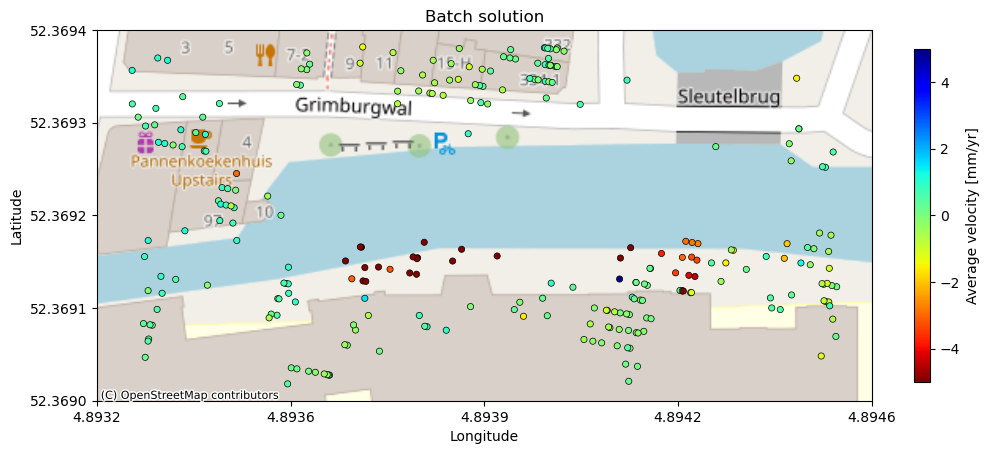

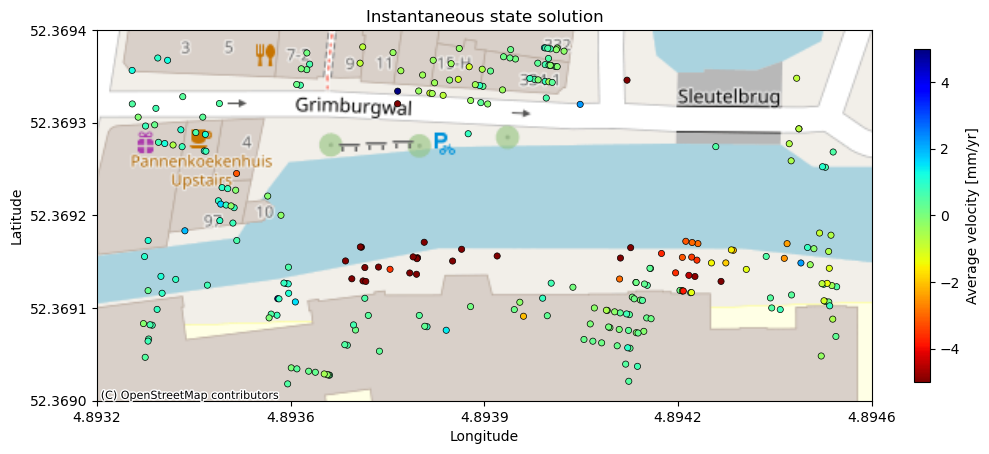

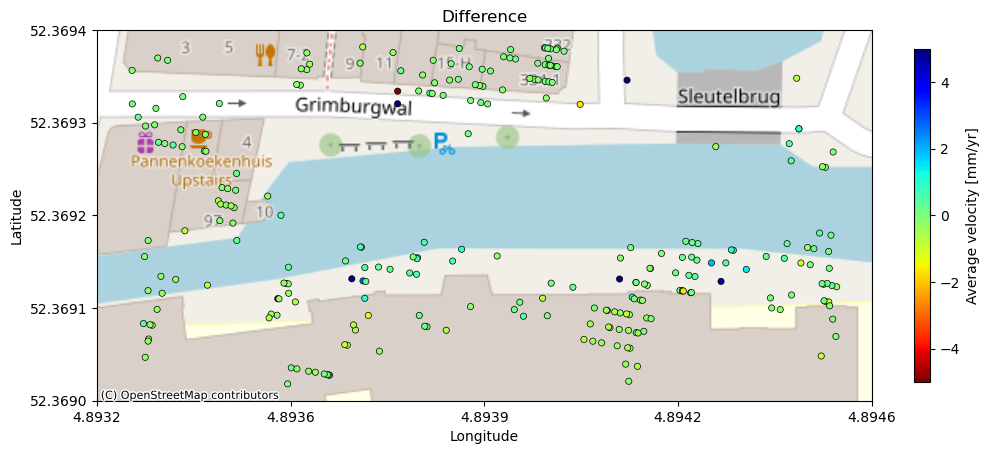

In [15]:
vel_list = [vel_lin_bat * 1000, vel_lin_rec * 1000, (vel_lin_bat - vel_lin_rec)*1000]

titles = ["Batch solution", "Instantaneous state solution", "Difference"]

for i in range(3):
    plot_insar_map(
        gdf_sub,
        values=vel_list[i],
        title=titles[i],
        vmin=-5,
        vmax=5,
        cmap='jet_r',
        point_size=20,
        zoom=19,
        fixed_color=None,
        cbar_label='Average velocity [mm/yr]'
    )

# difference
# mu, std = norm.fit(vel_list[2])

<div style="background-color:#FAE99E; color: black; vertical-align: middle; padding:3px 20px;">
<p>

## Question 2:
Compare the spatial difference between batch solution and instantaneous state solution, e.g., plot the histogram of the velocity difference.

</p>
</div>

# Example PS

In [16]:
pnts = [154,168,169,170,172,173,188,192,209,210,211]

154


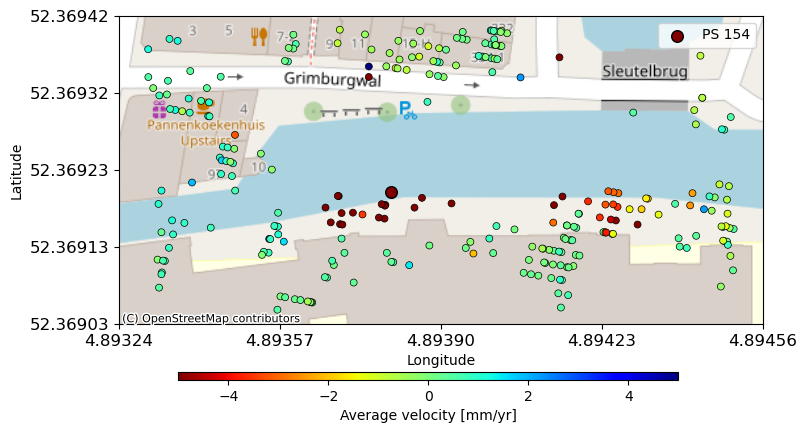

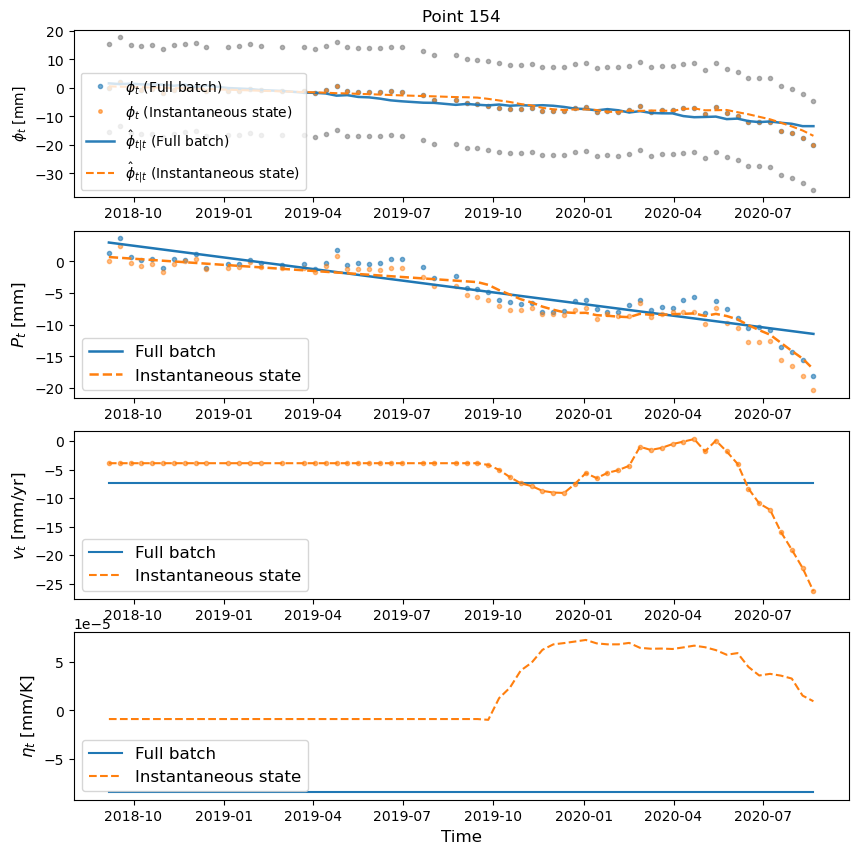

168


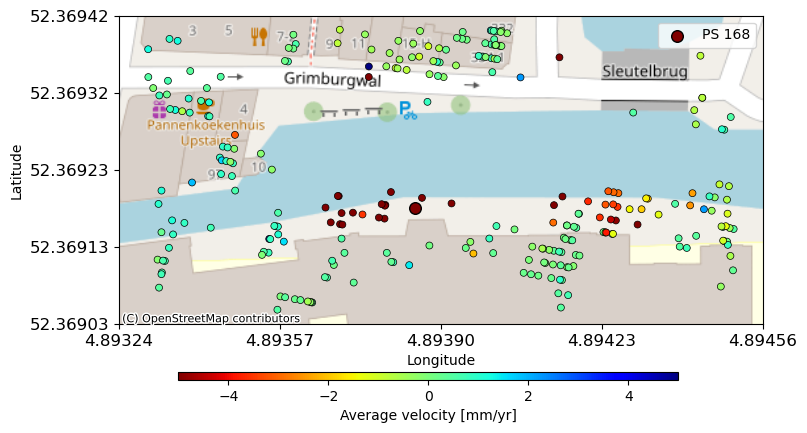

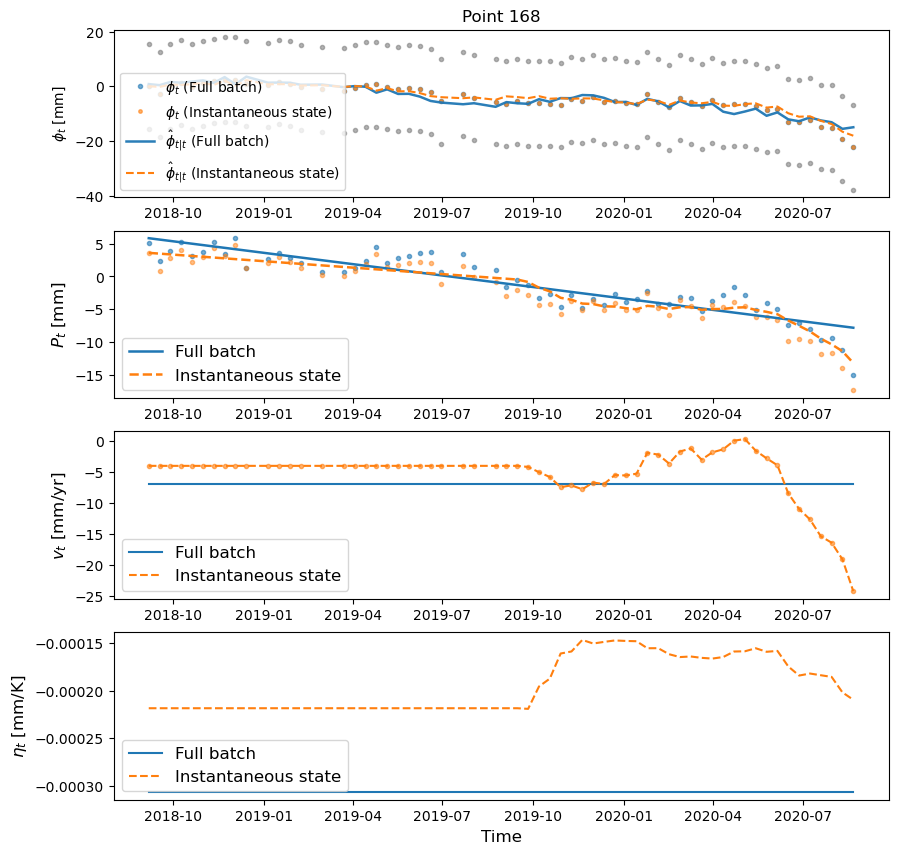

169


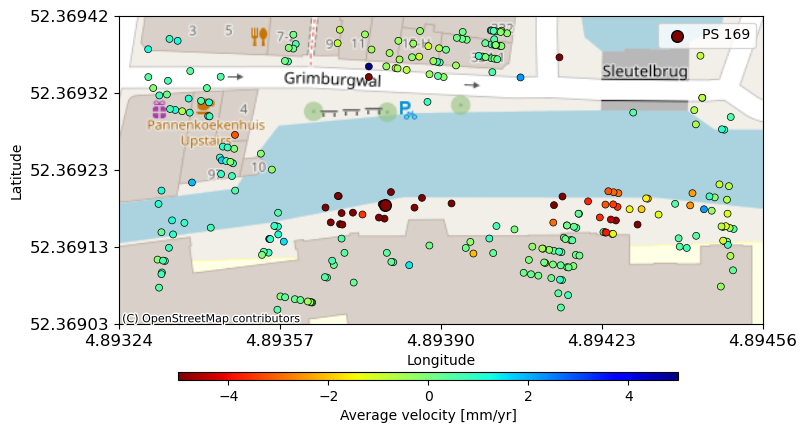

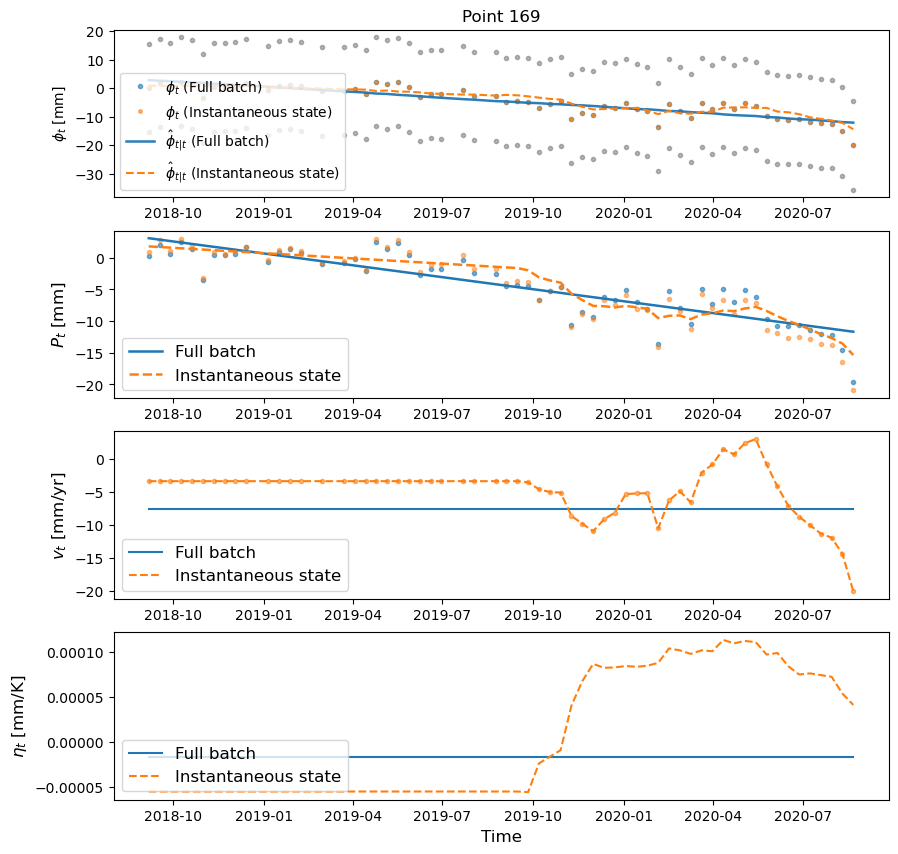

170


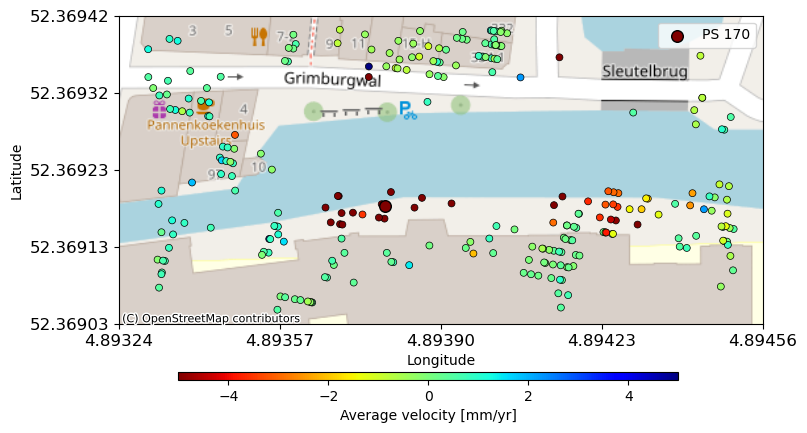

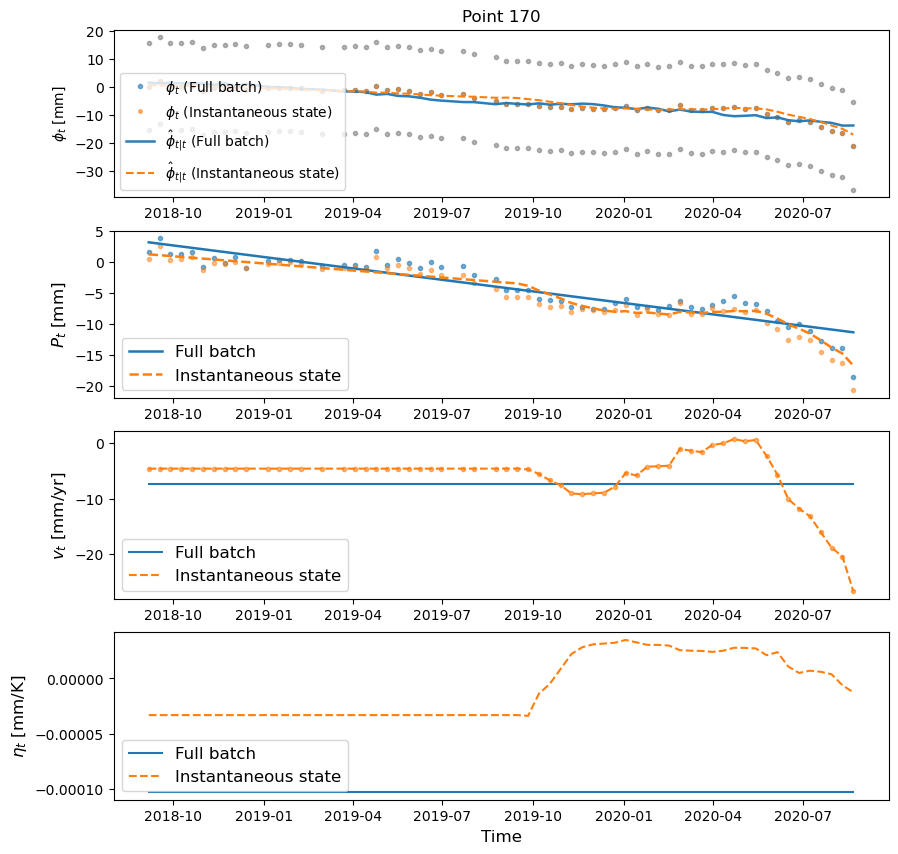

172


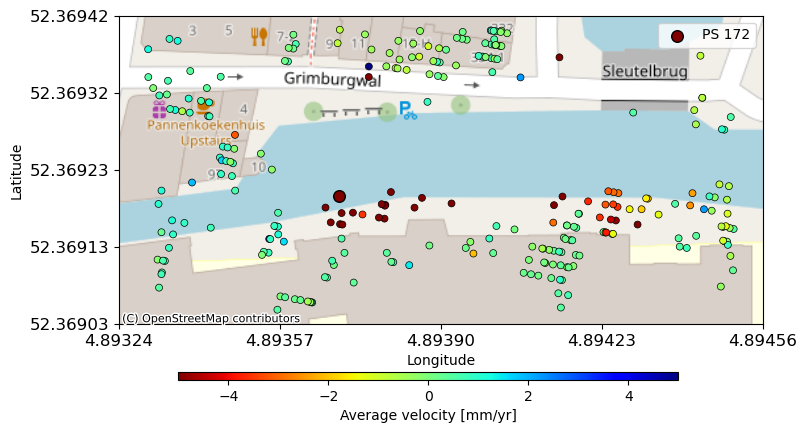

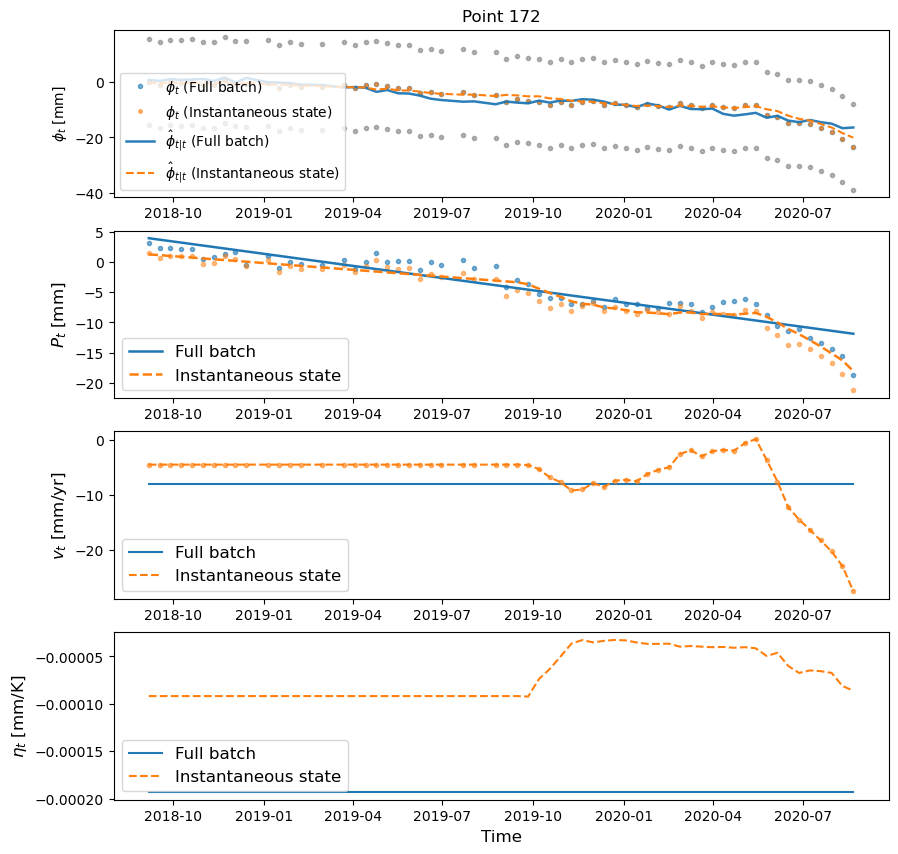

173


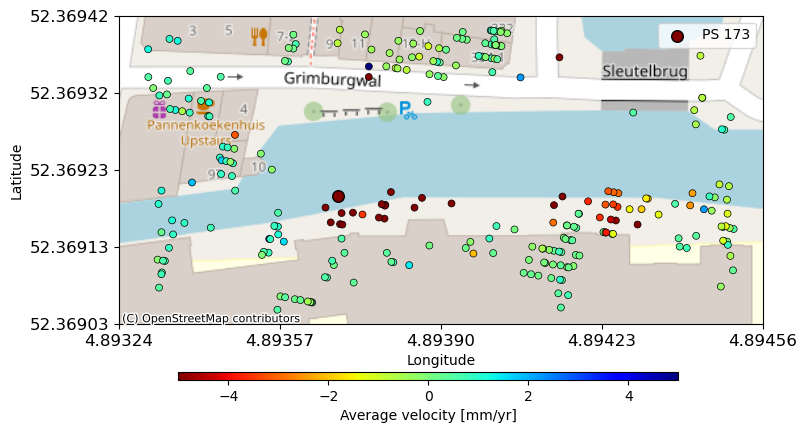

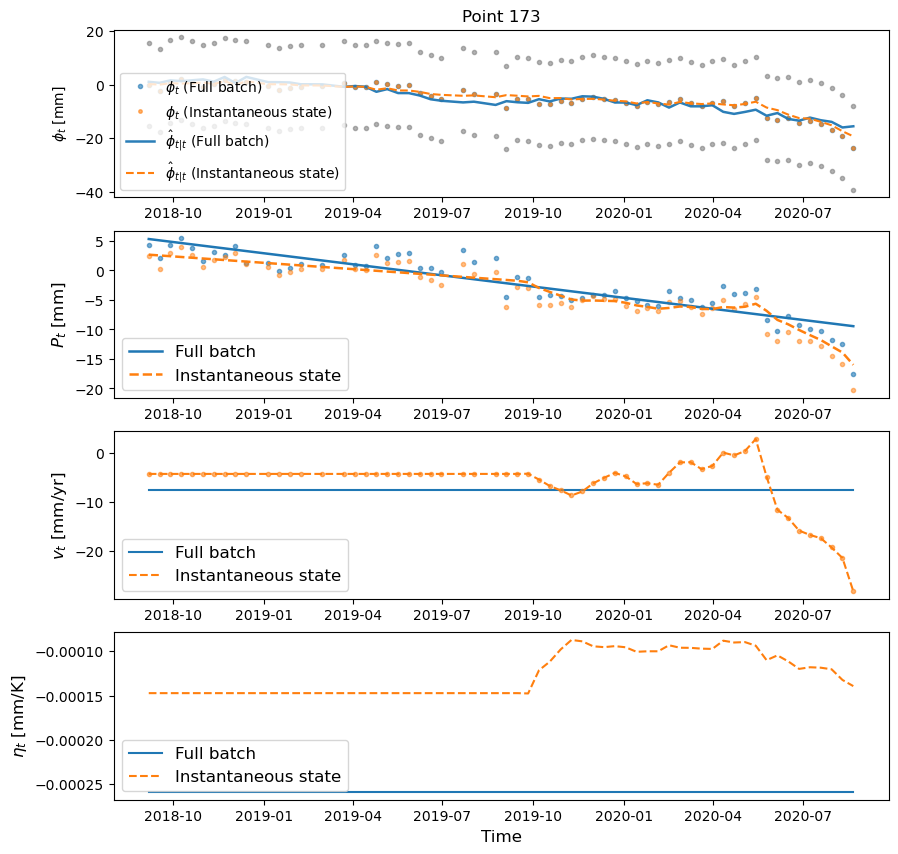

188


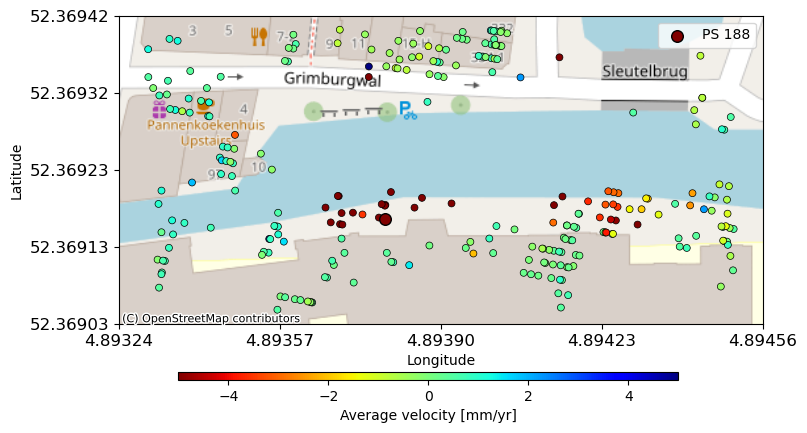

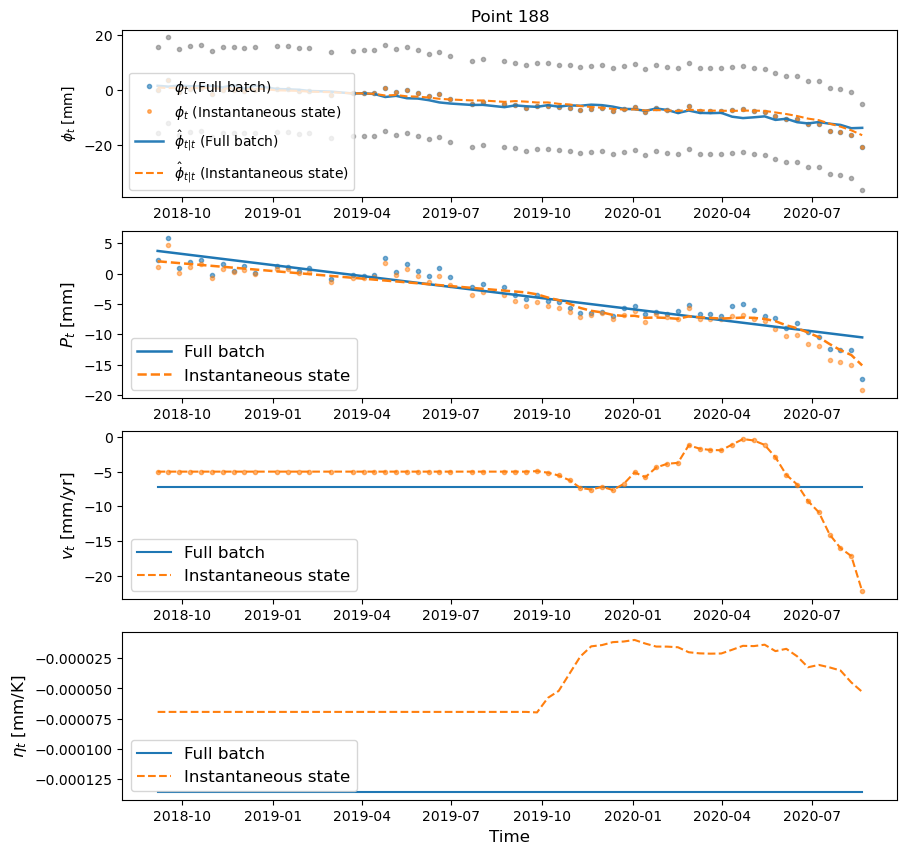

192


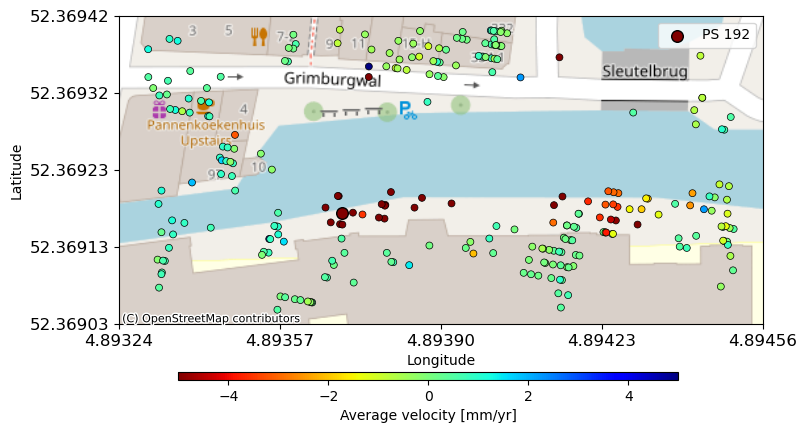

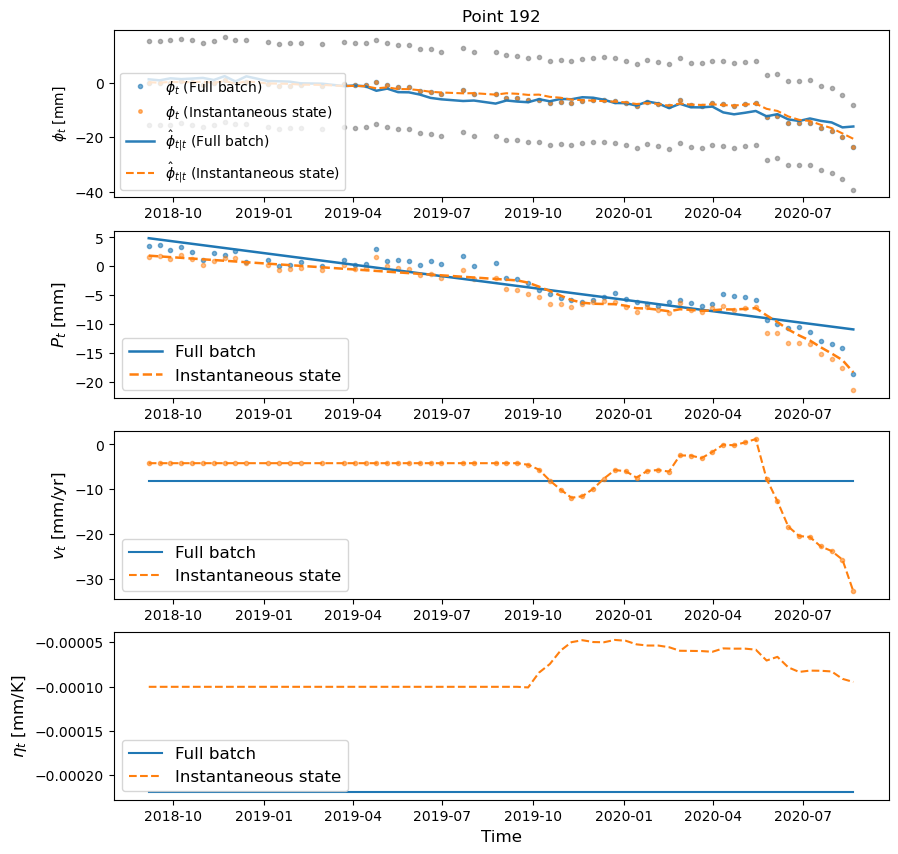

209


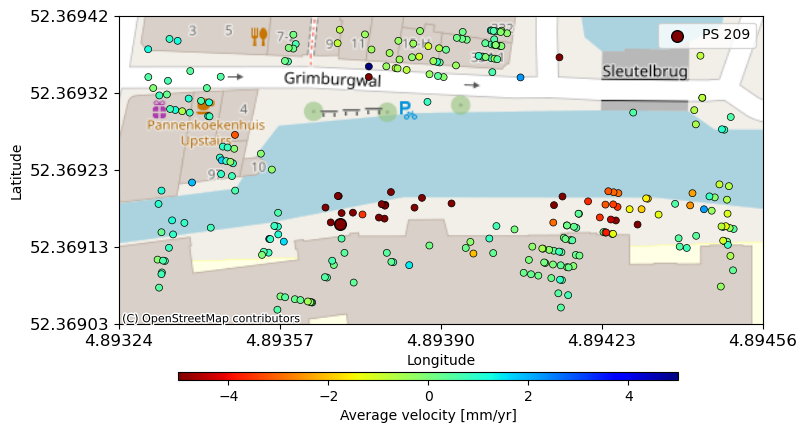

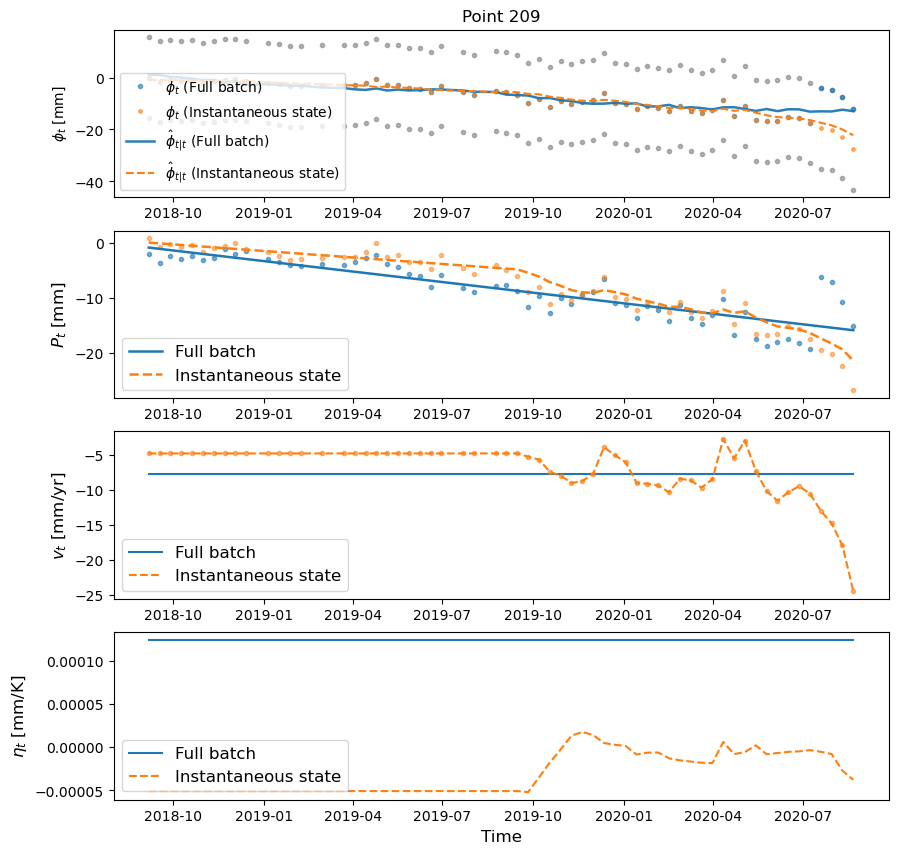

210


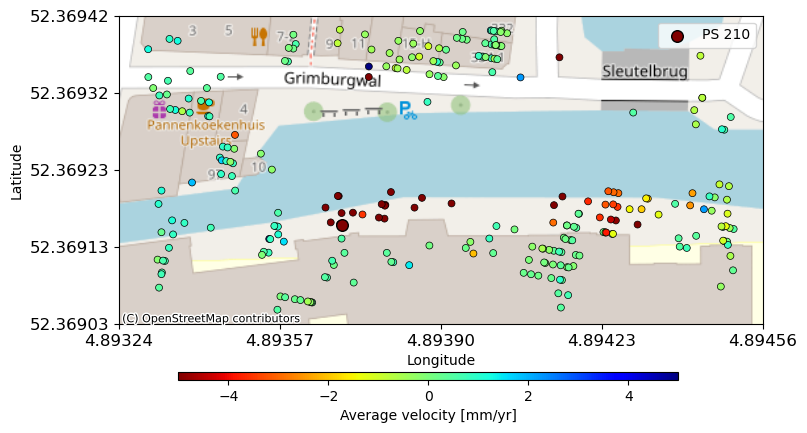

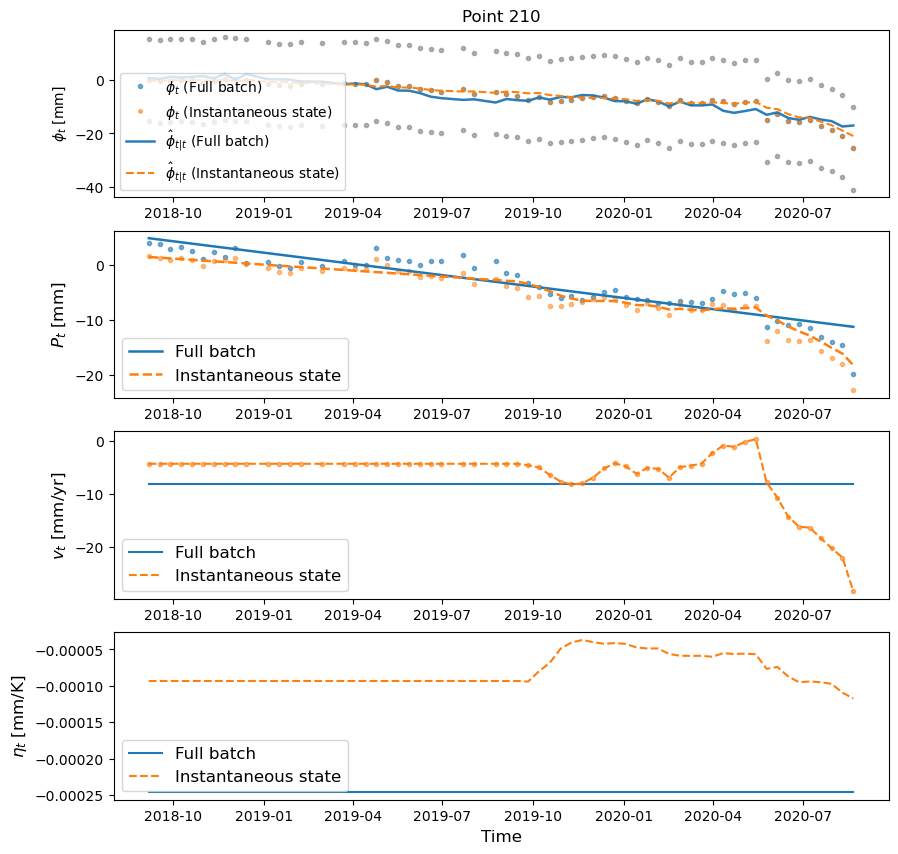

211


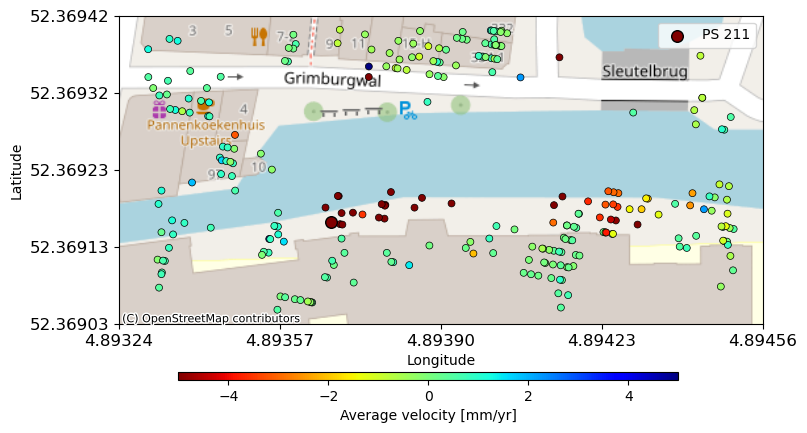

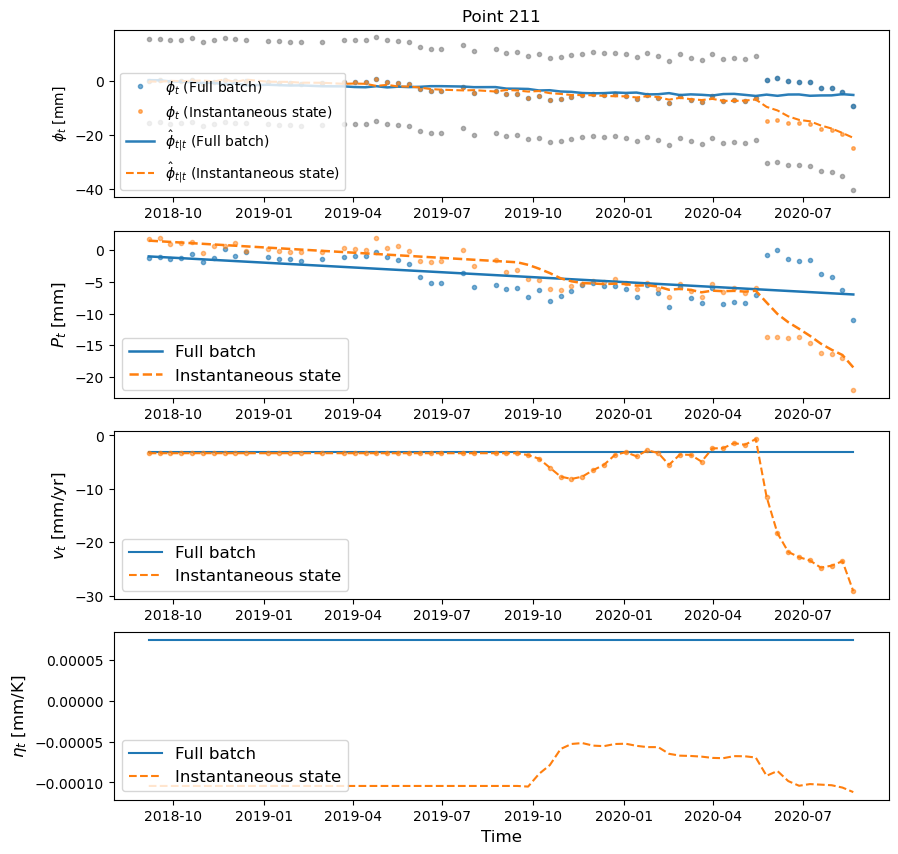

In [17]:
gdf_web = gdf_sub.to_crs(epsg=3857)

lon_sub = gdf_web.geometry.x.values
lat_sub = gdf_web.geometry.y.values
vel_sub = vel_lin_rec*1000

vmin = -5
vmax = 5

color_norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

for j in pnts:
        print(j)
        # get the phase time series
        def_pnt = gdf_sub.iloc[j][filter_def].to_numpy(dtype=float)
        # convert from meters to radians
        phs_wrapped = def_pnt*m2phs

        # get the amplitude time series
        amp_pnt = gdf_sub.iloc[j][filter_amp].to_numpy(dtype=float)

        # get the NMAD
        median_ampl, mad_ampl, nmad_pnt = NMAD(amp_pnt)

        # derive the quality (sigma) of the phase
        phs_sigma_pnt = NMAD_to_sigma_phase(nmad_pnt)
        nmad_pnt_ts = np.full(num_epochs, nmad_pnt)
        sigma_phs_apri = np.full(num_epochs, phs_sigma_pnt)

        # ===============================
        # Batch estimation
        # ===============================
        A = design_matrix_linear(wavelength, years, temp)
        x_hat, Q_xhat, y_hats, phs_unw = lambda_estimation(
                wavelength,
                phs_wrapped,
                sigma_phs_apri,
                years,
                temp,
                sigma_offset,
                sigma_vel,
                sigma_ther,
                method)

        # Get the phase for estimated DD observation, non-thermal displacement, height difference and thermal expension [rad]
        phs_est = A@x_hat
        dis_est =  A[:,:2]@x_hat[:2]
        phs_ther = A[:,2]*x_hat[2]

        # Get the phase for estimated DD observation, non-thermal displacement, height difference and thermal expension [mm]
        phs_est_mm = phs_est*phs2mm
        dis_est_mm = dis_est*phs2mm

        # # Get the wrapped and unwrapped phase [mm]
        phs_unw_mm = phs_unw*phs2mm

        vel_bat = x_hat[1]*1000
        ther = x_hat[2]

        # ===============================
        # instantaneous state estimation
        # ===============================
        # Calculate the unknowns with the recursive solution
        x_hats_fm, Qx_hats_fm, y_hats_fm, y_hats_unw_fm, x_hats_ft, Qx_hats_ft, y_hats_ft, y_hats_unw_ft = init_rec_estimation(
        init_len, wavelength, phs_wrapped, sigma_phs_apri, years, temp, sigma_v, L, sigma_offset, sigma_vel, sigma_ther, method, recursive_update)

        # The estimated position, instantaneous velocity, and thermal expansion factor
        dis_fm, vel_fm, ther_fm = x_hats_fm.T
        # The sum of position and residual
        dis_rec_fm = (y_hats_unw_fm - y_hats_fm)*(-wavelength/(4*np.pi))+dis_fm

        # calculate the constant valocity with a linear model
        y_fitted, poly_fn, coeffs = polynomial_fitting(years, dis_rec_fm, degree=1)
        vel_rec = coeffs[0]*1000


        # ===============================
        # Spatial plot
        # ===============================
        plt.figure(figsize=(10,4))
        ax = plt.subplot(1,1,1)
        sc = ax.scatter(lon_sub, lat_sub,
                        c=vel_sub, cmap='jet_r', norm=color_norm,
                        s=25, edgecolors='black', linewidths=0.5)

        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=19)
        ax.set_axis_on()

        ax.scatter(lon_sub[j], lat_sub[j],
                        c=vel_sub[j], cmap='jet_r', norm=color_norm,
                        s=70, edgecolors='black', linewidths=1, label = 'PS %s'%j)

        cbar_ax = plt.gcf().add_axes([0.25, -0.03, 0.5, 0.02])  # [left, bottom, width, height]
        cbar = plt.colorbar(sc, cax=cbar_ax, orientation='horizontal')
        cbar.set_label("Average velocity [mm/yr]")

        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()

        xticks = np.linspace(xmin, xmax, 5)
        yticks = np.linspace(ymin, ymax, 5)

        transformer = Transformer.from_crs("epsg:3857", "epsg:4326", always_xy=True)
        lon_labels = [f"{transformer.transform(x, ymin)[0]:.5f}" for x in xticks]
        lat_labels = [f"{transformer.transform(xmin, y)[1]:.5f}" for y in yticks]

        ax.set_xticks(xticks)
        ax.set_xticklabels(lon_labels)
        ax.set_yticks(yticks)
        ax.set_yticklabels(lat_labels)

        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.tick_params(labelsize=12)
        ax.legend(loc=1)
        ax.set_aspect('equal', adjustable='box')
        plt.subplots_adjust()
        plt.show()
        

        # Plot the time series
        plt.figure(figsize=(10, 10))

        # ===============================
        # DD Phase
        # ===============================
        ax = plt.subplot(4, 1, 1)
        ax.plot(insar_dates, y_hats_unw_fm*phs2mm-wavelength/2*1000, '.', markersize=6, color='gray', alpha=0.6)
        ax.plot(insar_dates, y_hats_unw_fm*phs2mm+wavelength/2*1000, '.', markersize=6, color='gray', alpha=0.6)
        sigma_phs_apri_mm = sigma_phs_apri*phs2mm

        ax.plot(insar_dates, phs_unw_mm, '.', markersize=6, color=color_full, alpha=0.6,
                label=rf'${{\phi}}_{{t}}$ (Full batch)')
        ax.plot(insar_dates, y_hats_unw_fm*phs2mm, '.', markersize=5, color=color_is, alpha=0.6,
                label=rf'${{\phi}}_{{t}}$ (Instantaneous state)')


        ax.plot(insar_dates, phs_est_mm, color=color_full, linewidth=1.8, alpha=0.95,
                label=rf'$\hat{{\phi}}_{{t|t}}$ (Full batch)')
        ax.plot(insar_dates, y_hats_fm*phs2mm, color=color_is, linestyle='--', linewidth=1.5,
                label=rf'$\hat{{\phi}}_{{t|t}}$ (Instantaneous state)')

        ax.set_ylabel(r'$\phi_t$ [mm]')
        ax.legend(loc=3)
        ax.set_title('Point %s'%j)


        # ===============================
        # Relative position
        # ===============================
        ax = plt.subplot(4, 1, 2)
        ax.plot(insar_dates, phs_unw_mm - phs_est_mm + dis_est_mm, '.', color=color_full, alpha=0.6,)
        ax.plot(insar_dates, dis_rec_fm*1000, '.', color=color_is, alpha=0.5,)

        ax.plot(insar_dates, dis_est_mm, color=color_full, linewidth=1.8,
                label='Full batch')
        ax.plot(insar_dates, dis_fm*1000, color=color_is, linestyle='--', linewidth=1.8,
                label='Instantaneous state')

        ax.set_ylabel(r'$P_t$ [mm]', size=12)
        ax.legend(loc=3, prop={'size':12})


        # ===============================
        # Velocity
        # ===============================
        ax = plt.subplot(4, 1, 3)
        ax.plot([insar_dates[0], insar_dates[-1]], [vel_bat, vel_bat], color=color_full, label='Full batch')
        ax.plot(insar_dates, vel_fm*1000, color=color_is, linestyle='--',
                label='Instantaneous state')
        ax.plot(insar_dates, vel_fm*1000, '.', markersize=6, color=color_is, alpha=0.6)

        ax.set_ylabel(r'$v_t$ [mm/yr]', size=12)
        ax.legend(loc=3, prop={'size':12})


        # ===============================
        # Thermal coefficient
        # ===============================
        ax = plt.subplot(4, 1, 4)
        ax.plot([insar_dates[0], insar_dates[-1]], [ther, ther], color=color_full,
                label='Full batch')
        ax.plot(insar_dates, ther_fm, color=color_is, linestyle='--',
                label='Instantaneous state')

        ax.set_ylabel(r'$\eta_t$ [mm/K]', size=12)
        ax.set_xlabel('Time', fontsize = 12)
        ax.legend(loc=3, prop={'size':12})

        
        plt.subplots_adjust(wspace = 0.15, hspace = 0.2)
        plt.show()


<div style="background-color:#FAE99E; color: black; vertical-align: middle; padding:3px 20px;">
<p>

## Question 3:
Select a random PS from the above `pnts` list, and compare the temporal difference between batch solution and instantaneous state solution, e.g., what are the differences for the estimated phase ($\phi_t$) and parameters/states [position $P_t$, velocity $v_t$]?


</p>
</div>

# Select an example PS

In [ ]:
pnts = [154,168,169,170,172,173,188,192,209,210,211]
j = 188

# Smoothness constraints

In [19]:
# ==============================================================
# define smoothness constraints 
# ==============================================================

# Smoothness No.1
sigma_v = 0.005 # m/yr^2
tau = 150/365 # yr

# Smoothness No.2
sigma_v1 = 0.01 # m/yr^2
tau1 = 150/365 # yr

# Smoothness No.3
sigma_v2 = 0.0001 # m/yr^2
tau2 = 30/365 # yr

# Smoothness No.4
sigma_v3 = 0.02 # m/yr^2
tau3 = 30/365 # yr

In [20]:
# ==============================================================
# IS Estimation with different smoothness constraints
# ==============================================================
# get the phase time series
def_pnt = gdf_sub.iloc[j][filter_def].to_numpy(dtype=float)
# convert from meters to radians
phs_wrapped = def_pnt*m2phs

# get the amplitude time series
amp_pnt = gdf_sub.iloc[j][filter_amp].to_numpy(dtype=float)

# get the NMAD
median_ampl, mad_ampl, nmad_pnt = NMAD(amp_pnt)

# derive the quality (sigma) of the phase
phs_sigma_pnt = NMAD_to_sigma_phase(nmad_pnt)
nmad_pnt_ts = np.full(num_epochs, nmad_pnt)
sigma_phs_apri = np.full(num_epochs, phs_sigma_pnt)


# ==============================================================
# Processing with smoothness constraint No.1
# ==============================================================
# Calculate the unknowns with the recursive solution
x_hats1_fm, Q_xhats1_fm, y_hats1_fm, y_hats_unw1_fm, x_hats1_ft, Q_xhats1_ft, y_hats1_ft, y_hats_unw1_ft = init_rec_estimation(
    init_len, wavelength, phs_wrapped, sigma_phs_apri, years, temp, sigma_v, tau, sigma_offset, sigma_vel, sigma_ther, method, recursive_update)

# The estimated phase
y_hats1_fm_mm = y_hats1_fm*phs2mm
# The absolute phase
y_hats_unw1_fm_mm = y_hats_unw1_fm*phs2mm


# ==============================================================
# Processing with smoothness constraint No.2
# ==============================================================
# Calculate the unknowns with the recursive solution
x_hats1_fm1, Q_xhats1_fm1, y_hats1_fm1, y_hats_unw1_fm1, x_hats1_ft1, Q_xhats1_ft1, y_hats1_ft1, y_hats_unw1_ft1 = init_rec_estimation(
    init_len, wavelength, phs_wrapped, sigma_phs_apri, years, temp, sigma_v1, tau1, sigma_offset, sigma_vel, sigma_ther, method, recursive_update)

# The estimated phase
y_hats1_fm_mm1 = y_hats1_fm1*phs2mm
# The absolute phase
y_hats_unw1_fm_mm1 = y_hats_unw1_fm1*phs2mm


# ==============================================================
# Processing with smoothness constraint No.3
# ==============================================================
# Calculate the unknowns with the recursive solution
x_hats1_fm2, Q_xhats1_fm2, y_hats1_fm2, y_hats_unw1_fm2, x_hats1_ft2, Q_xhats1_ft2, y_hats1_ft2, y_hats_unw1_ft2 = init_rec_estimation(
    init_len, wavelength, phs_wrapped, sigma_phs_apri, years, temp, sigma_v2, tau2, sigma_offset, sigma_vel, sigma_ther, method, recursive_update)

# The estimated phase
y_hats1_fm_mm2 = y_hats1_fm2*phs2mm
# The absolute phase
y_hats_unw1_fm_mm2 = y_hats_unw1_fm2*phs2mm


# ==============================================================
# Processing with smoothness constraint No.4
# ==============================================================
# Calculate the unknowns with the recursive solution
x_hats1_fm3, Q_xhats1_fm3, y_hats1_fm3, y_hats_unw1_fm3, x_hats1_ft3, Q_xhats1_ft3, y_hats1_ft3, y_hats_unw1_ft3 = init_rec_estimation(
    init_len, wavelength, phs_wrapped, sigma_phs_apri, years, temp, sigma_v3, tau3, sigma_offset, sigma_vel, sigma_ther, method, recursive_update)

# The estimated phase
y_hats1_fm_mm3 = y_hats1_fm3*phs2mm
# The absolute phase
y_hats_unw1_fm_mm3 = y_hats_unw1_fm3*phs2mm


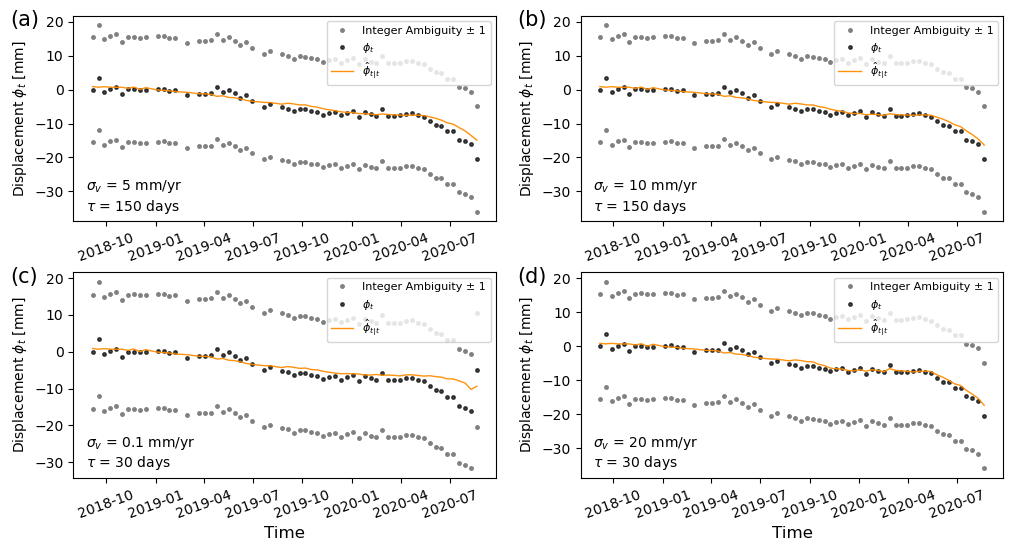

In [21]:
# ==============================================================
# Plot IS solutions with different smoothness constraints
# ==============================================================
plt.figure(figsize=(12, 6))

ax = plt.subplot(2, 2, 1)
ax.plot(insar_dates, y_hats_unw1_fm_mm + cycle_mm, '.', markersize=5, color='gray', label=rf'Integer Ambiguity ± 1')
ax.plot(insar_dates, y_hats_unw1_fm_mm - cycle_mm, '.', markersize=5, color='gray')
ax.plot(insar_dates, y_hats_unw1_fm_mm, '.', markersize=5, color='black', alpha=0.7, label=rf'${{\phi}}_{{t}}$')
ax.plot(insar_dates, y_hats1_fm_mm, color='darkorange', linestyle='-', linewidth=1, alpha=0.95, label=rf'$\hat{{\phi}}_{{t|t}}$')


ax.set_ylabel(r'Displacement $\phi_t$ [mm]', size=10)
ax.legend(loc=4, fontsize=8)
ax.text(-0.15, 0.95, '(a)', fontsize = 15, transform = ax.transAxes)
ax.legend(loc=1, fontsize=8)
for label in ax.get_xticklabels():
    label.set_rotation(20)
if sigma_v*1000 >=1:
        ax.text(0.03, 0.15, rf'$\sigma_v$ = {int(sigma_v*1000)} mm/yr', fontsize = 10, transform = ax.transAxes)
else:
    ax.text(0.03, 0.15, rf'$\sigma_v$ = {sigma_v*1000} mm/yr', fontsize = 10, transform = ax.transAxes)
ax.text(0.03, 0.05, rf'$\tau$ = {int(tau*365)} days', fontsize = 10, transform = ax.transAxes)



ax = plt.subplot(2, 2, 2)
ax.plot(insar_dates, y_hats_unw1_fm_mm1 + cycle_mm, '.', markersize=5, color='gray', label=rf'Integer Ambiguity ± 1')
ax.plot(insar_dates, y_hats_unw1_fm_mm1 - cycle_mm, '.', markersize=5, color='gray')
ax.plot(insar_dates, y_hats_unw1_fm_mm1, '.', markersize=5, color='black', alpha=0.7, label=rf'${{\phi}}_{{t}}$') 
ax.plot(insar_dates, y_hats1_fm_mm1, color='darkorange', linestyle='-', linewidth=1, alpha=0.95, label=rf'$\hat{{\phi}}_{{t|t}}$')# ($\sigma_v$ = {int(sigma_v1*1000)} mm/yr, $\tau$ = {int(tau1*365)} days)', zorder=10)

    

ax.set_ylabel(r'Displacement $\phi_t$ [mm]', size=10)
ax.legend(loc=4, fontsize=8)
ax.text(-0.15, 0.95, '(b)', fontsize = 15, transform = ax.transAxes)
ax.legend(loc=1, fontsize=8)
for label in ax.get_xticklabels():
    label.set_rotation(20)
if sigma_v1*1000 >=1:
        ax.text(0.03, 0.15, rf'$\sigma_v$ = {int(sigma_v1*1000)} mm/yr', fontsize = 10, transform = ax.transAxes)
else:
    ax.text(0.03, 0.15, rf'$\sigma_v$ = {sigma_v1*1000} mm/yr', fontsize = 10, transform = ax.transAxes)
ax.text(0.03, 0.05, rf'$\tau$ = {int(tau1*365)} days', fontsize = 10, transform = ax.transAxes)



ax = plt.subplot(2, 2, 3)
ax.plot(insar_dates, y_hats_unw1_fm_mm2 + cycle_mm, '.', markersize=5, color='gray', label=rf'Integer Ambiguity ± 1')
ax.plot(insar_dates, y_hats_unw1_fm_mm2 - cycle_mm, '.', markersize=5, color='gray')
ax.plot(insar_dates, y_hats_unw1_fm_mm2, '.', markersize=5, color='black', alpha=0.7, label=rf'${{\phi}}_{{t}}$') 
ax.plot(insar_dates, y_hats1_fm_mm2, color='darkorange', linestyle='-', linewidth=1, alpha=0.95, label=rf'$\hat{{\phi}}_{{t|t}}$')# ($\sigma_v$ = {int(sigma_v1*1000)} mm/yr, $\tau$ = {int(tau1*365)} days)', zorder=10)

    

ax.set_ylabel(r'Displacement $\phi_t$ [mm]', size=10)
ax.set_xlabel('Time', size=12)
ax.legend(loc=4, fontsize=8)
ax.text(-0.15, 0.95, '(c)', fontsize = 15, transform = ax.transAxes)
ax.legend(loc=1, fontsize=8)
for label in ax.get_xticklabels():
    label.set_rotation(20)
ax.set_xlabel('Time', size=12)
if sigma_v2*1000 >=1:
        ax.text(0.03, 0.15, rf'$\sigma_v$ = {int(sigma_v2*1000)} mm/yr', fontsize = 10, transform = ax.transAxes)
else:
    ax.text(0.03, 0.15, rf'$\sigma_v$ = {sigma_v2*1000} mm/yr', fontsize = 10, transform = ax.transAxes)
ax.text(0.03, 0.05, rf'$\tau$ = {int(tau2*365)} days', fontsize = 10, transform = ax.transAxes)



ax = plt.subplot(2, 2, 4)
ax.plot(insar_dates, y_hats_unw1_fm_mm3 + cycle_mm, '.', markersize=5, color='gray', label=rf'Integer Ambiguity ± 1')
ax.plot(insar_dates, y_hats_unw1_fm_mm3 - cycle_mm, '.', markersize=5, color='gray')
ax.plot(insar_dates, y_hats_unw1_fm_mm3, '.', markersize=5, color='black', alpha=0.7, label=rf'${{\phi}}_{{t}}$') 
ax.plot(insar_dates, y_hats1_fm_mm3, color='darkorange', linestyle='-', linewidth=1, alpha=0.95, label=rf'$\hat{{\phi}}_{{t|t}}$')

 
ax.set_ylabel(r'Displacement $\phi_t$ [mm]', size=10)
ax.legend(loc=4, fontsize=8)
ax.text(-0.15, 0.95, '(d)', fontsize = 15, transform = ax.transAxes)
ax.legend(loc=1, fontsize=8)
for label in ax.get_xticklabels():
    label.set_rotation(20)
ax.set_xlabel('Time', size=12)
if sigma_v3*1000 >=1:
        ax.text(0.03, 0.15, rf'$\sigma_v$ = {int(sigma_v3*1000)} mm/yr', fontsize = 10, transform = ax.transAxes)
else:
    ax.text(0.03, 0.15, rf'$\sigma_v$ = {sigma_v3*1000} mm/yr', fontsize = 10, transform = ax.transAxes)
ax.text(0.03, 0.05, rf'$\tau$ = {int(tau3*365)} days', fontsize = 10, transform = ax.transAxes)

plt.subplots_adjust(wspace=0.2,hspace=0.25)


<div style="background-color:#FAE99E; color: black; vertical-align: middle; padding:3px 20px;">
<p>

## Question 4:
Select a random PS from the above `pnts` list and tune the smoothness doublets ($[\sigma_v, \tau]$). How do these settings affect the estimated displacement?


</p>
</div>

# Anomaly detection

In [22]:
# ==============================================================
# Anomaly detection with smoothness No.1
# ==============================================================
T_1s = np.zeros(len(phs_wrapped), dtype=float)
anomaly_binaries1 = np.zeros(len(phs_wrapped), dtype=int)

# Loop through time steps
for k in range(init_len, len(phs_wrapped)):

    # Construct design matrix A
    A1 = np.array([m2phs, 0, temp[k] * m2phs])

    # Compute test statistic and detect anomalies
    T_1, anomaly_binary1, Q_res1 = anomaly_rec(alpha, q, phs_wrapped[k], y_hats1_ft[k], sigma_phs_apri[k], A1, Q_xhats1_ft[k])
    # Store results
    T_1s[k] = T_1.item()
    anomaly_binaries1[k] = anomaly_binary1
    
anomaly_index1 = [index for index, value in enumerate(anomaly_binaries1) if value == 1]


# ==============================================================
# Anomaly detection with smoothness No.2
# ==============================================================
T_1s_1 = np.zeros(len(phs_wrapped), dtype=float)
anomaly_binaries1_1 = np.zeros(len(phs_wrapped), dtype=int)

# Loop through time steps
for k in range(init_len, len(phs_wrapped)):

    # Construct design matrix A
    A1 = np.array([m2phs, 0, temp[k] * m2phs])

    # Compute test statistic and detect anomalies
    T_1_1, anomaly_binary1_1, Q_res1_1 = anomaly_rec(alpha, q, phs_wrapped[k], y_hats1_ft1[k], sigma_phs_apri[k], A1, Q_xhats1_ft1[k])
    # Store results
    T_1s_1[k] = T_1_1.item()
    anomaly_binaries1_1[k] = anomaly_binary1_1

        
anomaly_index1_1 = [index for index, value in enumerate(anomaly_binaries1_1) if value == 1]



# ==============================================================
# Anomaly detection with smoothness No.3
# ==============================================================
T_1s_2 = np.zeros(len(phs_wrapped), dtype=float)
anomaly_binaries1_2 = np.zeros(len(phs_wrapped), dtype=int)

# Loop through time steps
for k in range(init_len, len(phs_wrapped)):

    # Construct design matrix A
    A1 = np.array([m2phs, 0, temp[k] * m2phs])

    # Compute test statistic and detect anomalies
    T_1_2, anomaly_binary1_2, Q_res1_2 = anomaly_rec(alpha, q, phs_wrapped[k], y_hats1_ft2[k], sigma_phs_apri[k], A1, Q_xhats1_ft2[k])
    # Store results
    T_1s_2[k] = T_1_2.item()
    anomaly_binaries1_2[k] = anomaly_binary1_2

        
anomaly_index1_2 = [index for index, value in enumerate(anomaly_binaries1_2) if value == 1]


# ==============================================================
# Anomaly detection with smoothness No.4
# ==============================================================
T_1s_3 = np.zeros(len(phs_wrapped), dtype=float)
anomaly_binaries1_3 = np.zeros(len(phs_wrapped), dtype=int)


# Loop through time steps
for k in range(init_len, len(phs_wrapped)):

    # Construct design matrix A
    A1 = np.array([m2phs, 0, temp[k] * m2phs])
    # Compute test statistic and detect anomalies
    T_1_3, anomaly_binary1_3, Q_res1_3 = anomaly_rec(alpha, q, phs_wrapped[k], y_hats1_ft3[k], sigma_phs_apri[k], A1, Q_xhats1_ft3[k])
    # Store results
    T_1s_3[k] = T_1_3.item()
    anomaly_binaries1_3[k] = anomaly_binary1_3


anomaly_index1_3 = [index for index, value in enumerate(anomaly_binaries1_3) if value == 1]


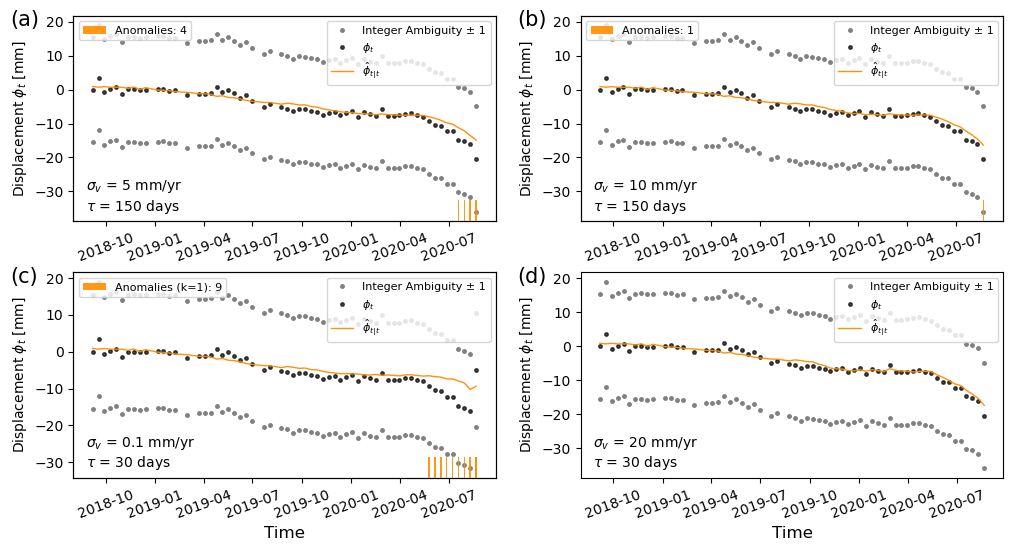

In [23]:
# Plot with different smoothness constraints
plt.figure(figsize=(12, 6))

# ==============================================================
# plot with smoothness No.1
# ==============================================================
ax = plt.subplot(2, 2, 1)
ax.plot(insar_dates, y_hats_unw1_fm_mm + cycle_mm, '.', markersize=5, color='gray', label=rf'Integer Ambiguity ± 1')
ax.plot(insar_dates, y_hats_unw1_fm_mm - cycle_mm, '.', markersize=5, color='gray')
ax.plot(insar_dates, y_hats_unw1_fm_mm, '.', markersize=5, color='black', alpha=0.7, label=rf'${{\phi}}_{{t}}$')
ax.plot(insar_dates, y_hats1_fm_mm, color='darkorange', linestyle='-', linewidth=1, alpha=0.95, label=rf'$\hat{{\phi}}_{{t|t}}$')
ax2 = ax.twinx()
ax2.set_ylim(0, 1)
if len(anomaly_index1) != 0:
    ax2.bar([insar_dates[m] for m in anomaly_index1], [0.1]*len(anomaly_index1),
            width=3,
            color='darkorange', alpha=0.9,
            label="Anomalies: %s" % len(anomaly_index1))
    
ax.set_ylabel(r'Displacement $\phi_t$ [mm]', size=10)
ax.legend(loc=4, fontsize=8)
ax.text(-0.15, 0.95, '(a)', fontsize = 15, transform = ax.transAxes)
ax.legend(loc=1, fontsize=8)
ax2.legend(loc=2, fontsize=8)
for label in ax.get_xticklabels():
    label.set_rotation(20)
ax2.get_yaxis().set_visible(False)
if sigma_v*1000 >=1:
        ax.text(0.03, 0.15, rf'$\sigma_v$ = {int(sigma_v*1000)} mm/yr', fontsize = 10, transform = ax.transAxes)
else:
    ax.text(0.03, 0.15, rf'$\sigma_v$ = {sigma_v*1000} mm/yr', fontsize = 10, transform = ax.transAxes)
ax.text(0.03, 0.05, rf'$\tau$ = {int(tau*365)} days', fontsize = 10, transform = ax.transAxes)




# ==============================================================
# plot with smoothness No.2
# ==============================================================
ax = plt.subplot(2, 2, 2)
ax.plot(insar_dates, y_hats_unw1_fm_mm1 + cycle_mm, '.', markersize=5, color='gray', label=rf'Integer Ambiguity ± 1')
ax.plot(insar_dates, y_hats_unw1_fm_mm1 - cycle_mm, '.', markersize=5, color='gray')
ax.plot(insar_dates, y_hats_unw1_fm_mm1, '.', markersize=5, color='black', alpha=0.7, label=rf'${{\phi}}_{{t}}$') 
ax.plot(insar_dates, y_hats1_fm_mm1, color='darkorange', linestyle='-', linewidth=1, alpha=0.95, label=rf'$\hat{{\phi}}_{{t|t}}$')
ax2 = ax.twinx()
ax2.set_ylim(0, 1)
if len(anomaly_index1_1) != 0:
    ax2.bar([insar_dates[m] for m in anomaly_index1_1], [0.1]*len(anomaly_index1_1),
            width=3,
            color='darkorange', alpha=0.9,
            label="Anomalies: %s" % len(anomaly_index1_1))


ax.set_ylabel(r'Displacement $\phi_t$ [mm]', size=10)
ax.legend(loc=4, fontsize=8)
ax.text(-0.15, 0.95, '(b)', fontsize = 15, transform = ax.transAxes)
ax.legend(loc=1, fontsize=8)
ax2.legend(loc=2, fontsize=8)
for label in ax.get_xticklabels():
    label.set_rotation(20)
ax2.get_yaxis().set_visible(False)
if sigma_v1*1000 >=1:
        ax.text(0.03, 0.15, rf'$\sigma_v$ = {int(sigma_v1*1000)} mm/yr', fontsize = 10, transform = ax.transAxes)
else:
    ax.text(0.03, 0.15, rf'$\sigma_v$ = {sigma_v1*1000} mm/yr', fontsize = 10, transform = ax.transAxes)
ax.text(0.03, 0.05, rf'$\tau$ = {int(tau1*365)} days', fontsize = 10, transform = ax.transAxes)




# ==============================================================
# plot with smoothness No.3
# ==============================================================
ax = plt.subplot(2, 2, 3)
ax.plot(insar_dates, y_hats_unw1_fm_mm2 + cycle_mm, '.', markersize=5, color='gray', label=rf'Integer Ambiguity ± 1')
ax.plot(insar_dates, y_hats_unw1_fm_mm2 - cycle_mm, '.', markersize=5, color='gray')
ax.plot(insar_dates, y_hats_unw1_fm_mm2, '.', markersize=5, color='black', alpha=0.7, label=rf'${{\phi}}_{{t}}$') 
ax.plot(insar_dates, y_hats1_fm_mm2, color='darkorange', linestyle='-', linewidth=1, alpha=0.95, label=rf'$\hat{{\phi}}_{{t|t}}$')

ax2 = ax.twinx()
ax2.set_ylim(0, 1)
if len(anomaly_index1_2) != 0: 
    ax2.bar([insar_dates[m] for m in anomaly_index1_2], [0.1]*len(anomaly_index1_2),
            width=3,
            color='darkorange', alpha=0.9,
            label="Anomalies (k=1): %s" % len(anomaly_index1_2))


ax.set_ylabel(r'Displacement $\phi_t$ [mm]', size=10)
ax.legend(loc=4, fontsize=8)
ax.text(-0.15, 0.95, '(c)', fontsize = 15, transform = ax.transAxes)
ax.legend(loc=1, fontsize=8)
ax2.legend(loc=2, fontsize=8)
for label in ax.get_xticklabels():
    label.set_rotation(20)
ax2.get_yaxis().set_visible(False)
ax.set_xlabel('Time', size=12)
if sigma_v2*1000 >=1:
        ax.text(0.03, 0.15, rf'$\sigma_v$ = {int(sigma_v2*1000)} mm/yr', fontsize = 10, transform = ax.transAxes)
else:
    ax.text(0.03, 0.15, rf'$\sigma_v$ = {sigma_v2*1000} mm/yr', fontsize = 10, transform = ax.transAxes)
ax.text(0.03, 0.05, rf'$\tau$ = {int(tau2*365)} days', fontsize = 10, transform = ax.transAxes)



# ==============================================================
# plot with smoothness No.4
# ==============================================================
ax = plt.subplot(2, 2, 4)
ax.plot(insar_dates, y_hats_unw1_fm_mm3 + cycle_mm, '.', markersize=5, color='gray', label=rf'Integer Ambiguity ± 1')
ax.plot(insar_dates, y_hats_unw1_fm_mm3 - cycle_mm, '.', markersize=5, color='gray')
ax.plot(insar_dates, y_hats_unw1_fm_mm3, '.', markersize=5, color='black', alpha=0.7, label=rf'${{\phi}}_{{t}}$') 
ax.plot(insar_dates, y_hats1_fm_mm3, color='darkorange', linestyle='-', linewidth=1, alpha=0.95, label=rf'$\hat{{\phi}}_{{t|t}}$')# ($\sigma_v$ = {sigma_v3*1000} mm/yr, $\tau$ = {int(tau3*365)} days)', zorder=10)

ax2.set_ylim(0, 1)
if len(anomaly_index1_3) != 0: 
    ax2.bar([insar_dates[m] for m in anomaly_index1_3], [0.1]*len(anomaly_index1_3),
            width=3,
            color='darkorange', alpha=0.9,
            label="Anomalies: %s" % len(anomaly_index1_3))

ax.set_ylabel(r'Displacement $\phi_t$ [mm]', size=10)
ax.legend(loc=4, fontsize=8)
ax.text(-0.15, 0.95, '(d)', fontsize = 15, transform = ax.transAxes)
ax.legend(loc=1, fontsize=8)
for label in ax.get_xticklabels():
    label.set_rotation(20)
ax.set_xlabel('Time', size=12)
if sigma_v3*1000 >=1:
        ax.text(0.03, 0.15, rf'$\sigma_v$ = {int(sigma_v3*1000)} mm/yr', fontsize = 10, transform = ax.transAxes)
else:
    ax.text(0.03, 0.15, rf'$\sigma_v$ = {sigma_v3*1000} mm/yr', fontsize = 10, transform = ax.transAxes)
ax.text(0.03, 0.05, rf'$\tau$ = {int(tau3*365)} days', fontsize = 10, transform = ax.transAxes)


plt.subplots_adjust(wspace=0.2,hspace=0.25)
plt.show()


<div style="background-color:#FAE99E; color: black; vertical-align: middle; padding:3px 20px;">
<p>

## Question 5:


How do the selected smoothness doblets affect the detected anomalies? Is a well-fitted model good for anomaly detection?
How should the smoothness doblets be chosen to enable timely and reliable anomaly detection?


</p>
</div>